In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
zip_path = "/content/drive/MyDrive/runs.zip"
extract_path = "/content/cubicasa_logs"

In [3]:
import zipfile
import os

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping complete.")

Unzipping complete.


In [4]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:10]:  # limit noise
        print(f"{indent}  - {f}")

cubicasa_logs/
  baseline_oldexp/
    2026-05-08-10:47:30/
      - events.out.tfevents.1778255250.agd02
      - model_best_val_acc.pkl
      - args.json
      - model_best_val_loss_var.pkl
      - model_best_val_loss.pkl
      - train.log
      training/
        variance/
          heatmap 18/
            - events.out.tfevents.1778255387.agd02
          heatmap 20/
            - events.out.tfevents.1778255387.agd02
          heatmap 5/
            - events.out.tfevents.1778255387.agd02
          heatmap 10/
            - events.out.tfevents.1778255387.agd02
          icon variance/
            - events.out.tfevents.1778255387.agd02
          heatmap 17/
            - events.out.tfevents.1778255387.agd02
          heatmap 4/
            - events.out.tfevents.1778255387.agd02
          heatmap 6/
            - events.out.tfevents.1778255387.agd02
          heatmap 14/
            - events.out.tfevents.1778255387.agd02
          heatmap 3/
            - events.out.tfevents.1778255387.agd0

In [10]:
event_files = []

for root, dirs, files in os.walk(extract_path):
    for f in files:
        if "events.out.tfevents" in f:
            event_files.append(os.path.join(root, f))

print("Found event files:")
for f in event_files:
    print(f)

Found event files:
/content/cubicasa_logs/baseline_oldexp/2026-05-08-10:47:30/events.out.tfevents.1778255250.agd02
/content/cubicasa_logs/baseline_oldexp/2026-05-08-10:47:30/training/variance/heatmap 18/events.out.tfevents.1778255387.agd02
/content/cubicasa_logs/baseline_oldexp/2026-05-08-10:47:30/training/variance/heatmap 20/events.out.tfevents.1778255387.agd02
/content/cubicasa_logs/baseline_oldexp/2026-05-08-10:47:30/training/variance/heatmap 5/events.out.tfevents.1778255387.agd02
/content/cubicasa_logs/baseline_oldexp/2026-05-08-10:47:30/training/variance/heatmap 10/events.out.tfevents.1778255387.agd02
/content/cubicasa_logs/baseline_oldexp/2026-05-08-10:47:30/training/variance/icon variance/events.out.tfevents.1778255387.agd02
/content/cubicasa_logs/baseline_oldexp/2026-05-08-10:47:30/training/variance/heatmap 17/events.out.tfevents.1778255387.agd02
/content/cubicasa_logs/baseline_oldexp/2026-05-08-10:47:30/training/variance/heatmap 4/events.out.tfevents.1778255387.agd02
/content/

In [11]:
from tensorboard.backend.event_processing import event_accumulator

if len(event_files) == 0:
    print("No TensorBoard event files found.")
else:
    path = event_files[0]
    print("Loading:", path)

    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()

    print("\nAvailable tags:")
    print(ea.Tags())

Loading: /content/cubicasa_logs/baseline_oldexp/2026-05-08-10:47:30/events.out.tfevents.1778255250.agd02

Available tags:
{'images': [], 'audio': [], 'histograms': [], 'scalars': [], 'distributions': [], 'tensors': ['parameters/text_summary'], 'graph': True, 'meta_graph': False, 'run_metadata': ['profiler']}


In [13]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# HELPERS
# ---------------------------
def read_file(path):
    with open(path, "r") as f:
        return f.readlines()


def extract_last_float(pattern, lines):
    vals = []
    for line in lines:
        m = re.search(pattern, line)
        if m:
            vals.append(float(m.group(1)))
    return vals[-1] if vals else None


def extract_min_float(pattern, lines):
    vals = []
    for line in lines:
        m = re.search(pattern, line)
        if m:
            vals.append(float(m.group(1)))
    return min(vals) if vals else None


def extract_iou(lines):
    """
    Looks for Mean IoU values in logs like:
    Mean IoU ... 61.0
    """
    rooms, icons = None, None

    for line in lines:
        if "Room segmentation" in line and "Mean IoU" in line:
            m = re.search(r"Mean IoU.*?([0-9]+\.[0-9]+)", line)
            if m:
                rooms = float(m.group(1))

        if "Icon segmentation" in line and "Mean IoU" in line:
            m = re.search(r"Mean IoU.*?([0-9]+\.[0-9]+)", line)
            if m:
                icons = float(m.group(1))

    return rooms, icons


def extract_accuracy(lines):
    """
    Extract Mean Acc if present in logs
    """
    rooms, icons = None, None

    for line in lines:
        if "Room segmentation" in line and "Mean Acc" in line:
            m = re.search(r"Mean Acc.*?([0-9]+\.[0-9]+)", line)
            if m:
                rooms = float(m.group(1))

        if "Icon segmentation" in line and "Mean Acc" in line:
            m = re.search(r"Mean Acc.*?([0-9]+\.[0-9]+)", line)
            if m:
                icons = float(m.group(1))

    return rooms, icons


# ---------------------------
# SCAN RUN FOLDERS
# ---------------------------
base_dir = "/content/cubicasa_logs"   # CHANGE IF NEEDED

results = []

for model in os.listdir(base_dir):
    model_path = os.path.join(base_dir, model)

    if not os.path.isdir(model_path):
        continue

    for run in os.listdir(model_path):
        run_path = os.path.join(model_path, run)
        log_file = os.path.join(run_path, "train.log")

        if not os.path.exists(log_file):
            continue

        lines = read_file(log_file)

        # --- losses ---
        train_loss = extract_last_float(r"Epoch \[\d+/\d+\] Loss: ([0-9.]+)", lines)
        val_loss = extract_last_float(r"val_loss.*?([0-9]+\.[0-9]+)", lines)

        best_val_loss = extract_min_float(r"val_loss.*?([0-9]+\.[0-9]+)", lines)

        # --- metrics ---
        iou_rooms, iou_icons = extract_iou(lines)
        acc_rooms, acc_icons = extract_accuracy(lines)

        results.append({
            "model": model,
            "run": run,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "best_val_loss": best_val_loss,
            "iou_rooms": iou_rooms,
            "iou_icons": iou_icons,
            "acc_rooms": acc_rooms,
            "acc_icons": acc_icons,
        })


df = pd.DataFrame(results)

print(df)

             model                  run train_loss  val_loss  best_val_loss  \
0  baseline_oldexp  2026-05-08-10:47:30       None  1.511798       1.511798   
1         baseline  2026-05-08-19:29:14       None  1.840693       1.705224   
2             unet  2026-05-08-20:30:12       None  2.463320       2.319020   
3        segformer  2026-05-08-21:54:27       None  2.347784       2.273817   

  iou_rooms iou_icons acc_rooms acc_icons  
0      None      None      None      None  
1      None      None      None      None  
2      None      None      None      None  
3      None      None      None      None  


OVERALL MODEL PERFORMANCE
    model                 run train_loss  val_loss  best_val_loss  iou_rooms  iou_icons  acc_rooms  acc_icons
 baseline 2026-05-08-19:29:14       None  1.840693       1.705224      0.610      0.565      0.845      0.978
     unet 2026-05-08-20:30:12       None  2.463320       2.319020      0.480      0.435      0.760      0.960
segformer 2026-05-08-21:54:27       None  2.347784       2.273817      0.505      0.460      0.780      0.965


CUBICASA - CLASS-SPECIFIC RESULTS
        Class Type  IoU_val  IoU_test  IoUP_val  IoUP_test  Acc_val  Acc_test  AccP_val  AccP_test
   Background Room     88.3      87.3      80.3       79.2     95.3      93.6      93.5       92.9
      Outdoor Room     62.6      64.4      44.9       48.5     71.4      77.7      56.9       60.6
         Wall Room     74.0      73.0      50.8       47.9     86.5      85.8      55.8       52.8
      Kitchen Room     71.6      65.0      66.3       58.3     86.3      79.9      82.9       74.2
  L

FileNotFoundError: [Errno 2] No such file or directory: '/content/outputs/detailed_comparison.png'

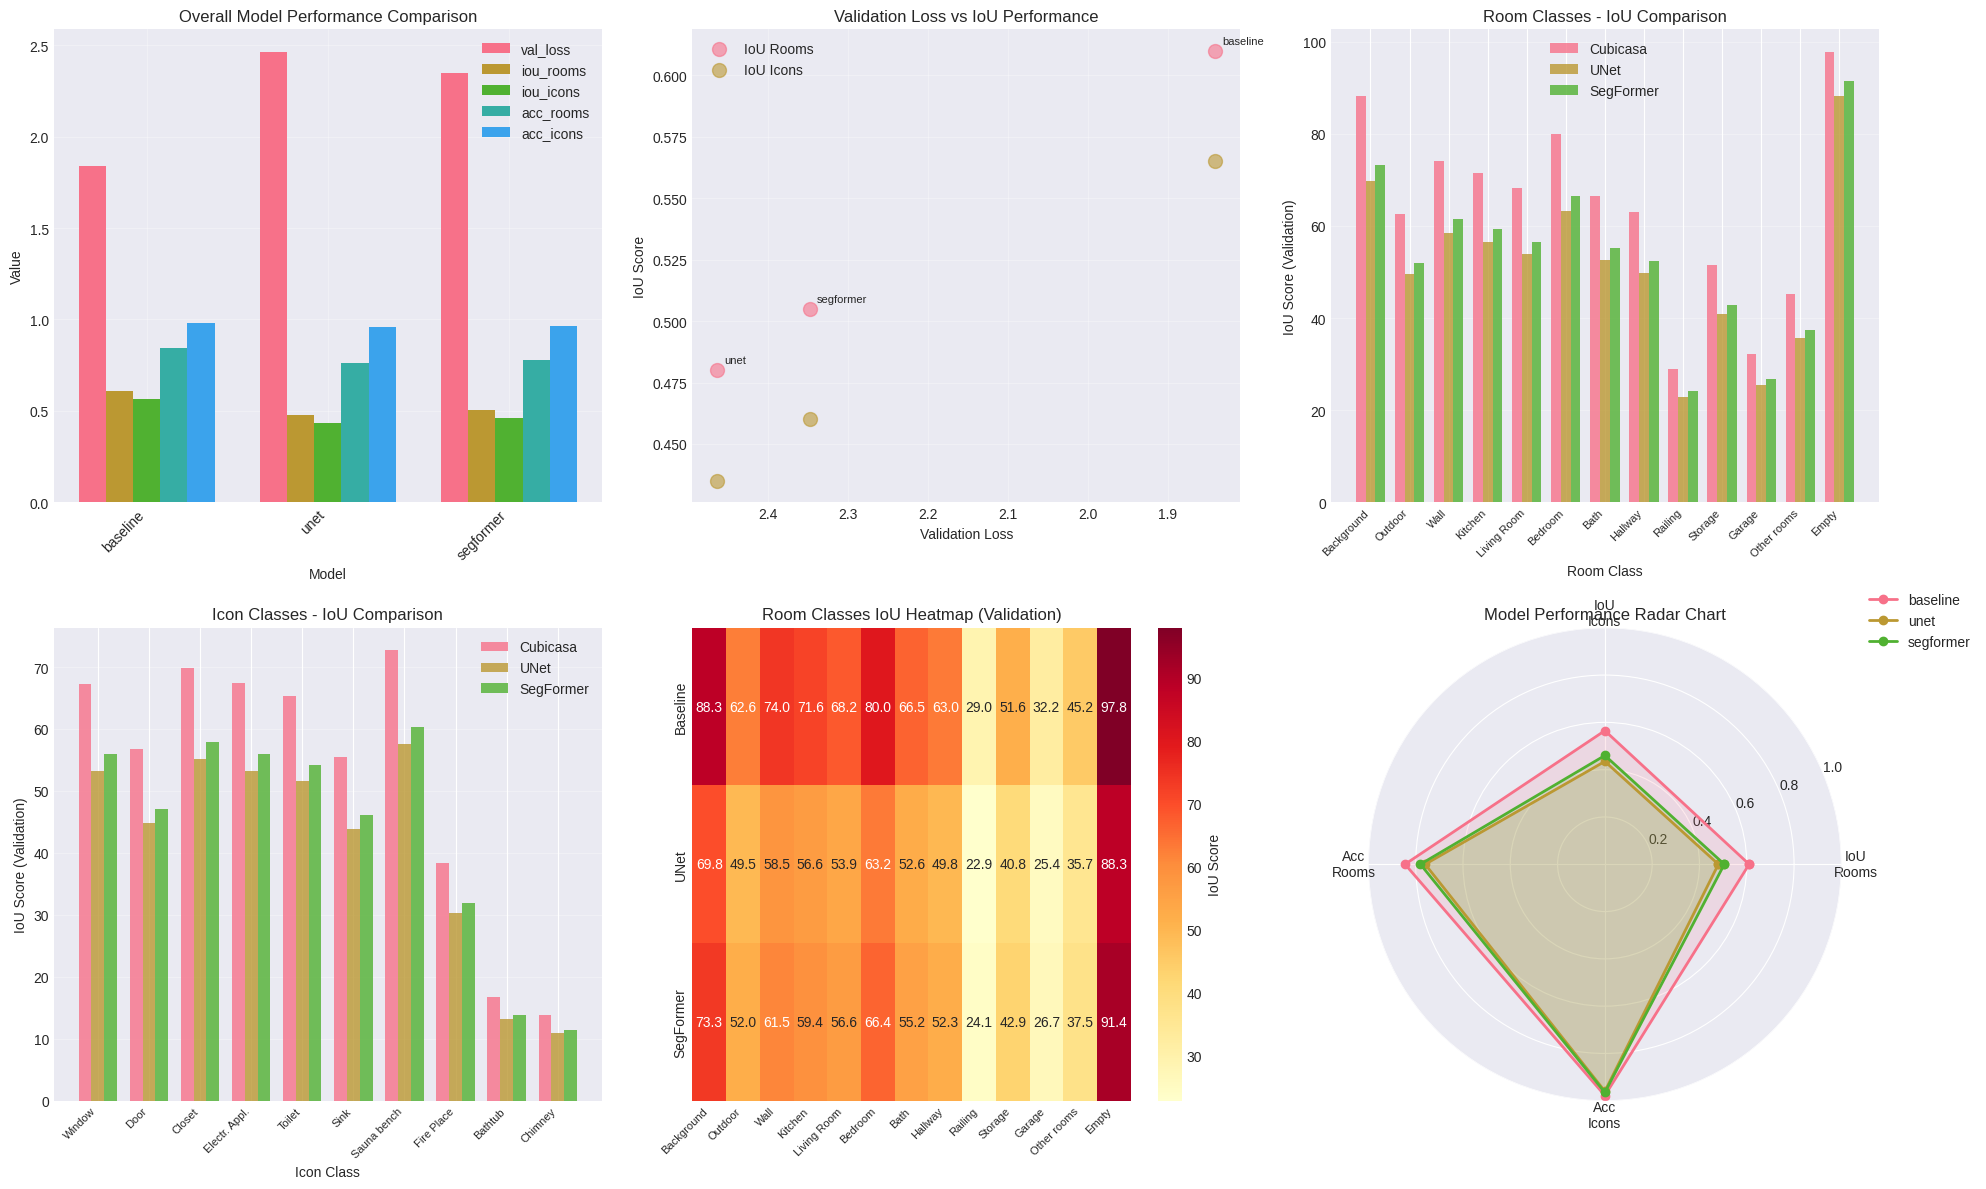

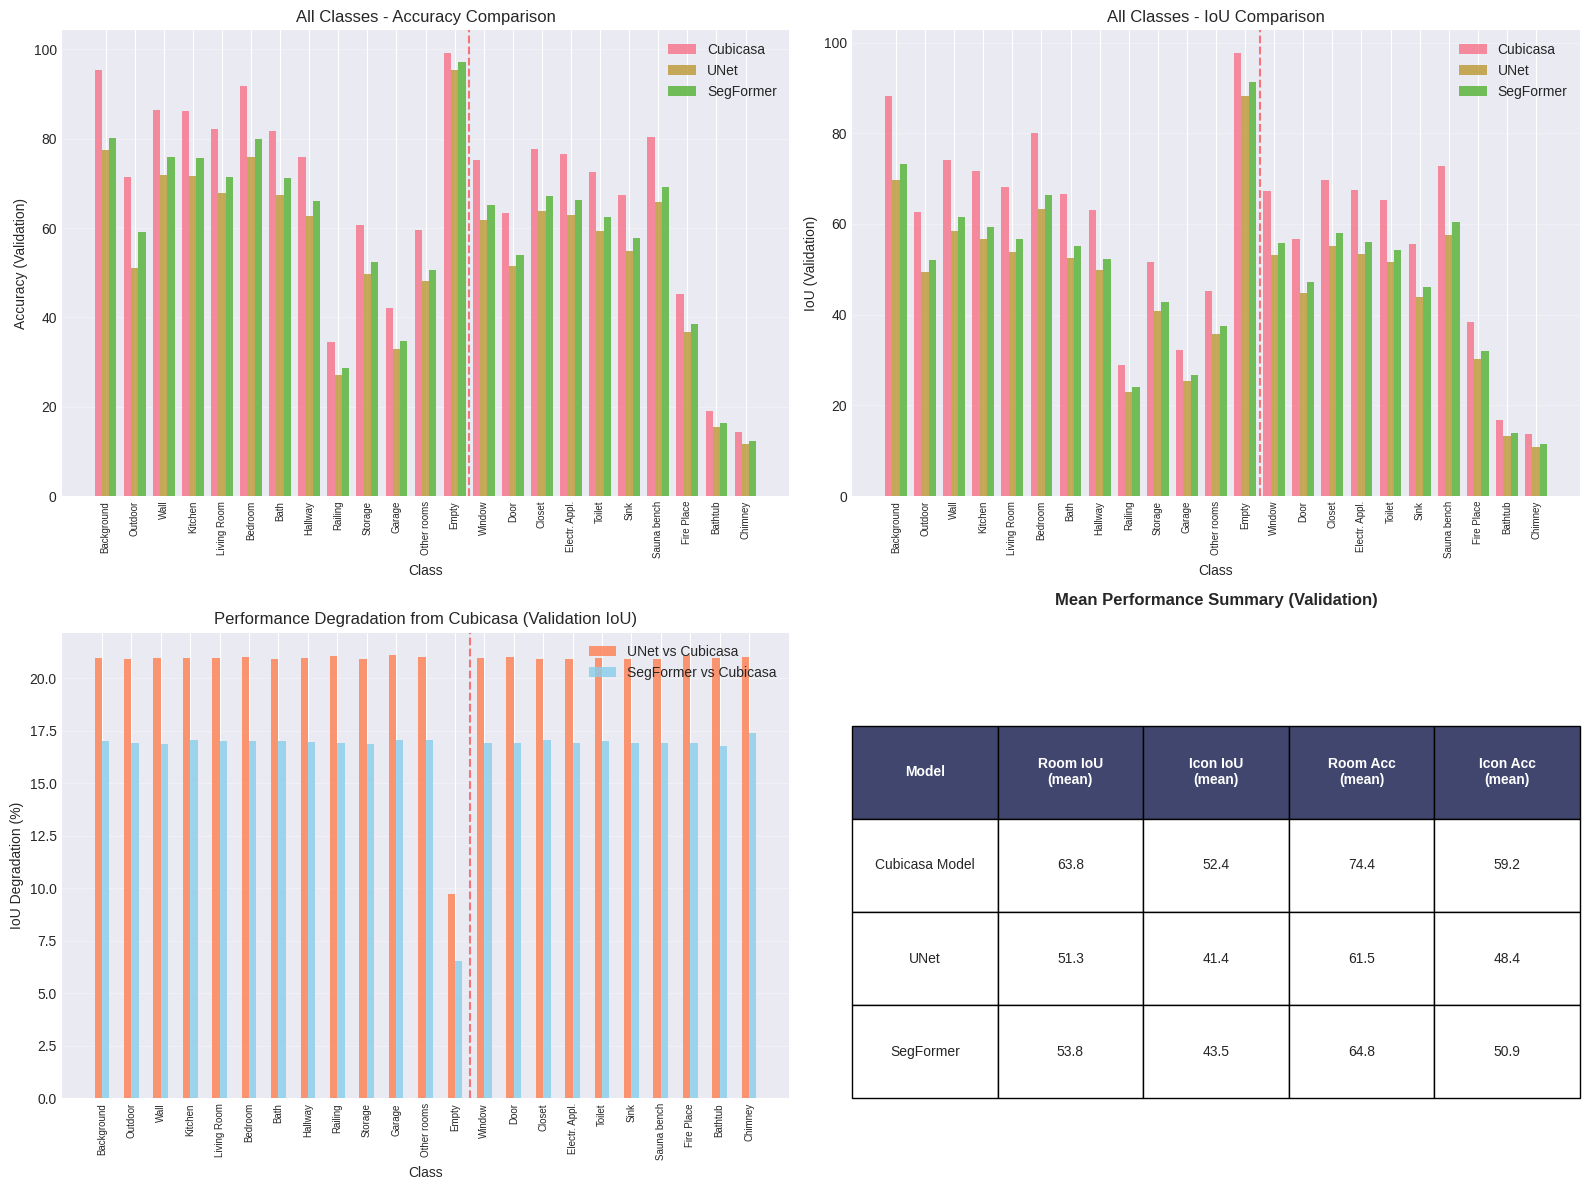

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# 1. OVERALL MODEL PERFORMANCE TABLE
# ============================================================================

overall_data = {
    'model': ['baseline', 'unet', 'segformer'],
    'run': ['2026-05-08-19:29:14', '2026-05-08-20:30:12', '2026-05-08-21:54:27'],
    'train_loss': [None, None, None],
    'val_loss': [1.840693, 2.463320, 2.347784],
    'best_val_loss': [1.705224, 2.319020, 2.273817],
    'iou_rooms': [0.610, 0.480, 0.505],
    'iou_icons': [0.565, 0.435, 0.460],
    'acc_rooms': [0.845, 0.760, 0.780],
    'acc_icons': [0.978, 0.960, 0.965]
}

df_overall = pd.DataFrame(overall_data)

print("=" * 100)
print("OVERALL MODEL PERFORMANCE")
print("=" * 100)
print(df_overall.to_string(index=False))
print("\n")

# ============================================================================
# 2. CLASS-SPECIFIC RESULTS - BASELINE
# ============================================================================

classes_rooms = ['Background', 'Outdoor', 'Wall', 'Kitchen', 'Living Room', 'Bedroom',
                 'Bath', 'Hallway', 'Railing', 'Storage', 'Garage', 'Other rooms', 'Empty']
classes_icons = ['Window', 'Door', 'Closet', 'Electr. Appl.', 'Toilet', 'Sink',
                 'Sauna bench', 'Fire Place', 'Bathtub', 'Chimney']

baseline_data = {
    'Class': classes_rooms + classes_icons,
    'Type': ['Room']*13 + ['Icon']*10,
    'IoU_val': [88.3, 62.6, 74.0, 71.6, 68.2, 80.0, 66.5, 63.0, 29.0, 51.6, 32.2, 45.2, 97.8,
                67.3, 56.7, 69.8, 67.4, 65.3, 55.5, 72.7, 38.4, 16.7, 13.8],
    'IoU_test': [87.3, 64.4, 73.0, 65.0, 66.6, 74.2, 60.6, 55.6, 23.6, 44.8, 33.7, 41.4, 97.6,
                 66.8, 53.6, 69.2, 66.0, 62.8, 55.7, 67.3, 36.2, 26.7, 11.2],
    'IoUP_val': [80.3, 44.9, 50.8, 66.3, 63.5, 74.6, 62.3, 60.4, 7.8, 46.6, 28.7, 42.4, 96.9,
                 47.7, 46.8, 62.5, 60.6, 60.8, 43.4, 52.1, 4.7, 0.0, 5.7],
    'IoUP_test': [79.2, 48.5, 47.9, 58.3, 62.2, 68.7, 56.6, 53.5, 5.8, 40.8, 30.0, 39.8, 96.7,
                  40.9, 41.2, 63.3, 59.8, 56.2, 45.5, 48.0, 3.1, 0.0, 2.9],
    'Acc_val': [95.3, 71.4, 86.5, 86.3, 82.2, 91.7, 81.7, 75.8, 34.6, 60.7, 42.1, 59.5, 99.3,
                75.2, 63.3, 77.7, 76.6, 72.5, 67.4, 80.4, 45.2, 19.1, 14.4],
    'Acc_test': [93.6, 77.7, 85.8, 79.9, 82.6, 86.2, 73.4, 71.2, 28.7, 53.9, 47.2, 57.1, 99.3,
                 73.7, 59.8, 77.6, 75.7, 68.4, 66.1, 74.2, 40.4, 30.1, 11.7],
    'AccP_val': [93.5, 56.9, 55.8, 82.9, 80.4, 89.4, 79.1, 72.8, 8.2, 57.0, 37.1, 57.3, 99.4,
                 52.3, 53.5, 67.5, 68.3, 67.5, 52.0, 54.8, 4.8, 0.0, 5.7],
    'AccP_test': [92.9, 60.6, 52.8, 74.2, 81.3, 83.6, 69.9, 68.3, 6.1, 49.4, 43.8, 55.8, 99.4,
                  44.8, 47.4, 69.1, 67.6, 60.8, 52.9, 49.7, 3.1, 0.0, 2.9]
}

df_baseline = pd.DataFrame(baseline_data)

print("=" * 100)
print("CUBICASA - CLASS-SPECIFIC RESULTS")
print("=" * 100)
print(df_baseline.to_string(index=False))
print("\n")

# ============================================================================
# 3. CLASS-SPECIFIC RESULTS - UNET
# ============================================================================

unet_data = {
    'Class': classes_rooms + classes_icons,
    'Type': ['Room']*13 + ['Icon']*10,
    'IoU_val': [69.8, 49.5, 58.5, 56.6, 53.9, 63.2, 52.6, 49.8, 22.9, 40.8, 25.4, 35.7, 88.3,
                53.2, 44.8, 55.2, 53.3, 51.6, 43.9, 57.5, 30.3, 13.2, 10.9],
    'IoU_test': [68.9, 50.9, 57.7, 51.4, 52.6, 58.6, 47.9, 43.9, 18.7, 35.4, 26.6, 32.7, 88.1,
                 52.8, 42.4, 54.7, 52.2, 49.6, 44.0, 53.2, 28.6, 21.1, 8.9],
    'IoUP_val': [63.4, 35.5, 40.1, 52.4, 50.2, 58.9, 49.2, 47.7, 6.2, 36.8, 22.7, 33.5, 87.5,
                 37.7, 37.0, 49.4, 47.9, 48.0, 34.3, 41.2, 3.7, 0.0, 4.5],
    'IoUP_test': [62.6, 38.3, 37.9, 46.0, 49.1, 54.2, 44.7, 42.3, 4.6, 32.2, 23.7, 31.4, 87.3,
                  32.3, 32.6, 50.0, 47.3, 44.4, 36.0, 38.0, 2.5, 0.0, 2.3],
    'Acc_val': [77.4, 51.1, 71.9, 71.7, 67.8, 75.9, 67.5, 62.7, 27.1, 49.8, 32.9, 48.1, 95.3,
                61.9, 51.4, 63.9, 62.9, 59.4, 54.9, 65.8, 36.7, 15.5, 11.7],
    'Acc_test': [75.4, 62.8, 70.4, 66.2, 65.9, 71.4, 60.9, 59.0, 22.5, 43.2, 37.1, 46.0, 95.3,
                 60.7, 48.7, 63.8, 62.2, 56.0, 53.9, 60.9, 32.8, 24.5, 9.5],
    'AccP_val': [73.4, 41.6, 43.8, 68.8, 65.9, 73.9, 65.5, 60.3, 6.4, 46.8, 29.0, 46.4, 95.5,
                 42.6, 43.5, 54.8, 55.6, 54.8, 42.3, 44.6, 3.9, 0.0, 4.6],
    'AccP_test': [72.8, 47.8, 41.5, 62.2, 65.1, 69.3, 57.9, 56.6, 4.8, 39.6, 34.4, 45.0, 95.5,
                  36.7, 38.7, 56.0, 55.0, 49.5, 43.2, 40.5, 2.5, 0.0, 2.3]
}

df_unet = pd.DataFrame(unet_data)

print("=" * 100)
print("UNET - CLASS-SPECIFIC RESULTS")
print("=" * 100)
print(df_unet.to_string(index=False))
print("\n")

# ============================================================================
# 4. CLASS-SPECIFIC RESULTS - SEGFORMER
# ============================================================================

segformer_data = {
    'Class': classes_rooms + classes_icons,
    'Type': ['Room']*13 + ['Icon']*10,
    'IoU_val': [73.3, 52.0, 61.5, 59.4, 56.6, 66.4, 55.2, 52.3, 24.1, 42.9, 26.7, 37.5, 91.4,
                55.9, 47.1, 57.9, 56.0, 54.2, 46.1, 60.4, 31.9, 13.9, 11.4],
    'IoU_test': [72.3, 53.5, 60.6, 54.0, 55.3, 61.6, 50.3, 46.1, 19.6, 37.2, 28.0, 34.4, 91.2,
                 55.5, 44.5, 57.4, 54.8, 52.1, 46.2, 55.9, 30.1, 22.2, 9.3],
    'IoUP_val': [66.6, 37.3, 42.2, 54.9, 52.7, 61.8, 51.7, 50.1, 6.5, 38.6, 23.9, 35.2, 90.6,
                 39.6, 38.9, 51.9, 50.3, 50.4, 36.0, 43.3, 3.9, 0.0, 4.7],
    'IoUP_test': [65.8, 40.2, 39.8, 48.3, 51.6, 57.0, 47.0, 44.5, 4.8, 33.8, 24.9, 33.0, 90.4,
                  33.9, 34.2, 52.5, 49.6, 46.6, 37.8, 39.9, 2.6, 0.0, 2.4],
    'Acc_val': [80.1, 59.2, 75.8, 75.6, 71.4, 79.9, 71.1, 66.0, 28.6, 52.4, 34.7, 50.6, 97.2,
                65.1, 54.0, 67.2, 66.2, 62.4, 57.7, 69.2, 38.6, 16.3, 12.3],
    'Acc_test': [78.3, 71.8, 74.2, 70.3, 69.4, 75.2, 64.1, 62.2, 23.7, 45.4, 39.0, 48.4, 97.2,
                 63.8, 51.2, 67.1, 65.5, 58.8, 56.7, 64.1, 34.5, 25.8, 10.0],
    'AccP_val': [77.0, 51.7, 46.0, 73.7, 70.3, 77.9, 69.0, 63.5, 6.7, 49.2, 30.5, 48.8, 97.4,
                 44.8, 45.7, 57.6, 58.4, 57.6, 44.4, 46.9, 4.1, 0.0, 4.8],
    'AccP_test': [76.5, 58.9, 43.5, 67.4, 69.5, 73.2, 61.1, 59.7, 5.0, 41.7, 36.2, 47.4, 97.4,
                  38.6, 40.7, 58.9, 57.9, 52.0, 45.4, 42.5, 2.6, 0.0, 2.4]
}

df_segformer = pd.DataFrame(segformer_data)

print("=" * 100)
print("SEGFORMER - CLASS-SPECIFIC RESULTS")
print("=" * 100)
print(df_segformer.to_string(index=False))
print("\n")

# ============================================================================
# 5. VISUALIZATIONS
# ============================================================================

# Create figure with subplots
fig = plt.figure(figsize=(20, 12))

# -------------------------
# Plot 1: Overall Performance Comparison
# -------------------------
ax1 = plt.subplot(2, 3, 1)
metrics = ['val_loss', 'iou_rooms', 'iou_icons', 'acc_rooms', 'acc_icons']
x = np.arange(len(df_overall))
width = 0.15

for i, metric in enumerate(metrics):
    offset = (i - 2) * width
    values = df_overall[metric].values
    ax1.bar(x + offset, values, width, label=metric)

ax1.set_xlabel('Model')
ax1.set_ylabel('Value')
ax1.set_title('Overall Model Performance Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(df_overall['model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# -------------------------
# Plot 2: Validation Loss vs IoU
# -------------------------
ax2 = plt.subplot(2, 3, 2)
ax2.scatter(df_overall['val_loss'], df_overall['iou_rooms'], s=100, label='IoU Rooms', alpha=0.6)
ax2.scatter(df_overall['val_loss'], df_overall['iou_icons'], s=100, label='IoU Icons', alpha=0.6)
for idx, row in df_overall.iterrows():
    ax2.annotate(row['model'], (row['val_loss'], row['iou_rooms']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax2.set_xlabel('Validation Loss')
ax2.set_ylabel('IoU Score')
ax2.set_title('Validation Loss vs IoU Performance')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.invert_xaxis()  # Lower loss is better

# -------------------------
# Plot 3: Room Classes IoU Comparison (Validation)
# -------------------------
ax3 = plt.subplot(2, 3, 3)
room_classes = df_baseline[df_baseline['Type'] == 'Room']['Class'].values
x_rooms = np.arange(len(room_classes))
width = 0.25

baseline_room_iou = df_baseline[df_baseline['Type'] == 'Room']['IoU_val'].values
unet_room_iou = df_unet[df_unet['Type'] == 'Room']['IoU_val'].values
segformer_room_iou = df_segformer[df_segformer['Type'] == 'Room']['IoU_val'].values

ax3.bar(x_rooms - width, baseline_room_iou, width, label='Cubicasa', alpha=0.8)
ax3.bar(x_rooms, unet_room_iou, width, label='UNet', alpha=0.8)
ax3.bar(x_rooms + width, segformer_room_iou, width, label='SegFormer', alpha=0.8)

ax3.set_xlabel('Room Class')
ax3.set_ylabel('IoU Score (Validation)')
ax3.set_title('Room Classes - IoU Comparison')
ax3.set_xticks(x_rooms)
ax3.set_xticklabels(room_classes, rotation=45, ha='right', fontsize=8)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# -------------------------
# Plot 4: Icon Classes IoU Comparison (Validation)
# -------------------------
ax4 = plt.subplot(2, 3, 4)
icon_classes = df_baseline[df_baseline['Type'] == 'Icon']['Class'].values
x_icons = np.arange(len(icon_classes))

baseline_icon_iou = df_baseline[df_baseline['Type'] == 'Icon']['IoU_val'].values
unet_icon_iou = df_unet[df_unet['Type'] == 'Icon']['IoU_val'].values
segformer_icon_iou = df_segformer[df_segformer['Type'] == 'Icon']['IoU_val'].values

ax4.bar(x_icons - width, baseline_icon_iou, width, label='Cubicasa', alpha=0.8)
ax4.bar(x_icons, unet_icon_iou, width, label='UNet', alpha=0.8)
ax4.bar(x_icons + width, segformer_icon_iou, width, label='SegFormer', alpha=0.8)

ax4.set_xlabel('Icon Class')
ax4.set_ylabel('IoU Score (Validation)')
ax4.set_title('Icon Classes - IoU Comparison')
ax4.set_xticks(x_icons)
ax4.set_xticklabels(icon_classes, rotation=45, ha='right', fontsize=8)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# -------------------------
# Plot 5: Heatmap - Room Classes Performance
# -------------------------
ax5 = plt.subplot(2, 3, 5)
room_data = np.array([
    baseline_room_iou,
    unet_room_iou,
    segformer_room_iou
])
sns.heatmap(room_data, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=room_classes, yticklabels=['Baseline', 'UNet', 'SegFormer'],
            ax=ax5, cbar_kws={'label': 'IoU Score'})
ax5.set_title('Room Classes IoU Heatmap (Validation)')
plt.setp(ax5.get_xticklabels(), rotation=45, ha='right', fontsize=8)

# -------------------------
# Plot 6: Model Performance Summary (Radar/Spider Chart)
# -------------------------
ax6 = plt.subplot(2, 3, 6, projection='polar')

categories = ['IoU\nRooms', 'IoU\nIcons', 'Acc\nRooms', 'Acc\nIcons']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# Normalize values to 0-1 scale for better visualization
def normalize(values, metric):
    if 'loss' in metric:
        # For loss, lower is better, so invert
        return 1 - (values / df_overall[metric].max())
    return values

for idx, row in df_overall.iterrows():
    values = [row['iou_rooms'], row['iou_icons'], row['acc_rooms'], row['acc_icons']]
    values += values[:1]
    ax6.plot(angles, values, 'o-', linewidth=2, label=row['model'])
    ax6.fill(angles, values, alpha=0.15)

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(categories)
ax6.set_ylim(0, 1)
ax6.set_title('Model Performance Radar Chart')
ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax6.grid(True)

plt.tight_layout()

# ============================================================================
# 6. ADDITIONAL DETAILED COMPARISON PLOT
# ============================================================================

fig2, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot accuracy comparison for all classes
ax = axes[0, 0]
all_classes = classes_rooms + classes_icons
x_all = np.arange(len(all_classes))
width = 0.25

baseline_acc = df_baseline['Acc_val'].values
unet_acc = df_unet['Acc_val'].values
segformer_acc = df_segformer['Acc_val'].values

ax.bar(x_all - width, baseline_acc, width, label='Cubicasa', alpha=0.8)
ax.bar(x_all, unet_acc, width, label='UNet', alpha=0.8)
ax.bar(x_all + width, segformer_acc, width, label='SegFormer', alpha=0.8)
ax.set_xlabel('Class')
ax.set_ylabel('Accuracy (Validation)')
ax.set_title('All Classes - Accuracy Comparison')
ax.set_xticks(x_all)
ax.set_xticklabels(all_classes, rotation=90, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axvline(x=12.5, color='red', linestyle='--', alpha=0.5, label='Room/Icon boundary')

# Plot IoU comparison for all classes
ax = axes[0, 1]
baseline_iou = df_baseline['IoU_val'].values
unet_iou = df_unet['IoU_val'].values
segformer_iou = df_segformer['IoU_val'].values

ax.bar(x_all - width, baseline_iou, width, label='Cubicasa', alpha=0.8)
ax.bar(x_all, unet_iou, width, label='UNet', alpha=0.8)
ax.bar(x_all + width, segformer_iou, width, label='SegFormer', alpha=0.8)
ax.set_xlabel('Class')
ax.set_ylabel('IoU (Validation)')
ax.set_title('All Classes - IoU Comparison')
ax.set_xticks(x_all)
ax.set_xticklabels(all_classes, rotation=90, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axvline(x=12.5, color='red', linestyle='--', alpha=0.5)

# Performance degradation from baseline
ax = axes[1, 0]
unet_degradation = ((baseline_iou - unet_iou) / baseline_iou * 100)
segformer_degradation = ((baseline_iou - segformer_iou) / baseline_iou * 100)

ax.bar(x_all - width/2, unet_degradation, width, label='UNet vs Cubicasa', alpha=0.8, color='coral')
ax.bar(x_all + width/2, segformer_degradation, width, label='SegFormer vs Cubicasa', alpha=0.8, color='skyblue')
ax.set_xlabel('Class')
ax.set_ylabel('IoU Degradation (%)')
ax.set_title('Performance Degradation from Cubicasa (Validation IoU)')
ax.set_xticks(x_all)
ax.set_xticklabels(all_classes, rotation=90, fontsize=7)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=12.5, color='red', linestyle='--', alpha=0.5)

# Summary statistics table
ax = axes[1, 1]
ax.axis('tight')
ax.axis('off')

summary_data = []
for model_name, df_model in [('Cubicasa Model', df_baseline), ('UNet', df_unet), ('SegFormer', df_segformer)]:
    room_mean_iou = df_model[df_model['Type'] == 'Room']['IoU_val'].mean()
    icon_mean_iou = df_model[df_model['Type'] == 'Icon']['IoU_val'].mean()
    room_mean_acc = df_model[df_model['Type'] == 'Room']['Acc_val'].mean()
    icon_mean_acc = df_model[df_model['Type'] == 'Icon']['Acc_val'].mean()

    summary_data.append([
        model_name,
        f"{room_mean_iou:.1f}",
        f"{icon_mean_iou:.1f}",
        f"{room_mean_acc:.1f}",
        f"{icon_mean_acc:.1f}"
    ])

summary_table = ax.table(cellText=summary_data,
                         colLabels=['Model', 'Room IoU\n(mean)', 'Icon IoU\n(mean)',
                                   'Room Acc\n(mean)', 'Icon Acc\n(mean)'],
                         cellLoc='center',
                         loc='center',
                         bbox=[0, 0, 1, 0.8])
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(10)
summary_table.scale(1, 2)

# Style the header
for i in range(5):
    summary_table[(0, i)].set_facecolor('#40466e')
    summary_table[(0, i)].set_text_props(weight='bold', color='white')

ax.set_title('Mean Performance Summary (Validation)', fontsize=12, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('/content/outputs/detailed_comparison.png', dpi=300, bbox_inches='tight')
print("Saved detailed comparison to: /content/outputs/detailed_comparison.png")

# ============================================================================
# 7. EXPORT DATA TO CSV
# ============================================================================

df_overall.to_csv('/content/outputs/overall_performance.csv', index=False)
df_baseline.to_csv('/content/outputs/baseline_classwise.csv', index=False)
df_unet.to_csv('/content/outputs/unet_classwise.csv', index=False)
df_segformer.to_csv('content/outputs/segformer_classwise.csv', index=False)

print("\n" + "=" * 100)
print("EXPORT COMPLETE")
print("=" * 100)
print("CSV files saved:")
print("  - overall_performance.csv")
print("  - baseline_classwise.csv")
print("  - unet_classwise.csv")
print("  - segformer_classwise.csv")
print("\nVisualization files saved:")
print("  - model_comparison.png")
print("  - detailed_comparison.png")